# 👁️ Eye Blink Rate Detector
## Movie Watching vs. Document Reading

Measures your blink rate (blinks/second) across two 1-minute sessions:
- **Movie** — watch a video on screen
- **Reading** — read one page of a document

**Compatible with MediaPipe ≥ 0.10** (uses the new `mediapipe.tasks` API).

```bash
pip install opencv-python mediapipe numpy matplotlib
```

---
## Cell 1 — Imports & Configuration

In [1]:
import cv2, time, os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import warnings
warnings.filterwarnings('ignore')

# ── Tunable parameters ────────────────────────────────────────────
MOVIE_DURATION   = 60    # seconds
READING_DURATION = 60    # seconds
EAR_THRESHOLD    = 0.21  # EAR below this → eye closed
CONSEC_FRAMES    = 2     # consecutive closed frames needed to register a blink
# ─────────────────────────────────────────────────────────────────

# MediaPipe landmark indices for EAR (same as the classic 468-pt model)
LEFT_EYE_V  = [(159, 145), (158, 153), (157, 154)]
LEFT_EYE_H  = (33, 133)
RIGHT_EYE_V = [(386, 374), (385, 380), (384, 381)]
RIGHT_EYE_H = (362, 263)

print('✅ Imports OK')
print(f'   MediaPipe version : {mp.__version__}')
print(f'   Movie session     : {MOVIE_DURATION}s')
print(f'   Reading session   : {READING_DURATION}s')

✅ Imports OK
   MediaPipe version : 0.10.32
   Movie session     : 60s
   Reading session   : 60s


---
## Cell 2 — Download Face Landmarker Model
_Run once. The `.task` file (~3 MB) is cached to `/tmp`._

In [6]:
import tempfile, os, urllib.request

MODEL_PATH = os.path.join(tempfile.gettempdir(), 'face_landmarker.task')
MODEL_URL  = (
    'https://storage.googleapis.com/mediapipe-models/'
    'face_landmarker/face_landmarker/float16/latest/face_landmarker.task'
)

if not os.path.exists(MODEL_PATH):
    print('Downloading face_landmarker.task (~3 MB) …')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f'  Saved → {MODEL_PATH}')
else:
    print(f'✅ Model already cached: {MODEL_PATH}')

print(f'   File size: {os.path.getsize(MODEL_PATH)/1e6:.1f} MB')

  Saved → C:\Users\jc301368\AppData\Local\Temp\face_landmarker.task
   File size: 3.8 MB


---
## Cell 3 — Core EAR & Recording Functions

In [ ]:
def ear_from_landmarks(landmarks, v_pairs, h_pair):
    """
    Compute the Eye Aspect Ratio (EAR) for one eye.

    EAR = average vertical eyelid distance / horizontal eye width

    When the eye is open, vertical distances are large → EAR is high (~0.3+).
    When the eye closes (blink), vertical distances collapse → EAR drops (~0.15).
    Dividing by the horizontal width makes EAR scale-independent (works at any
    distance from the camera).

    Args:
        landmarks : list of NormalizedLandmark for the whole face
        v_pairs   : list of (top_idx, bottom_idx) landmark pairs along the eyelid
        h_pair    : (left_corner_idx, right_corner_idx) for eye width
    """
    def pt(idx):
        # Extract (x, y) from the normalised landmark (coords are in [0, 1])
        lm = landmarks[idx]
        return np.array([lm.x, lm.y])

    # Average the vertical distances across the 3 eyelid pairs.
    # Using 3 pairs (instead of 1) makes EAR more robust to asymmetric blinks.
    vertical   = np.mean([np.linalg.norm(pt(a) - pt(b)) for a, b in v_pairs])

    # Single horizontal measurement — the full eye width acts as the denominator
    horizontal = np.linalg.norm(pt(h_pair[0]) - pt(h_pair[1]))

    return float(vertical / horizontal) if horizontal > 1e-6 else 0.0


def build_detector():
    """
    Create a MediaPipe FaceLandmarker configured for VIDEO mode.

    VIDEO mode (vs IMAGE mode) enables temporal tracking across frames —
    MediaPipe uses the previous frame's result to seed the next detection,
    which is faster and more stable than re-detecting from scratch each frame.
    """
    base_opts = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=base_opts,
        running_mode=mp_vision.RunningMode.VIDEO,  # frame-by-frame with timestamps
        num_faces=1,                               # we only care about the subject
        min_face_detection_confidence=0.5,         # minimum score to accept a new face detection
        min_face_presence_confidence=0.5,          # minimum score to keep tracking an existing face
        min_tracking_confidence=0.5,               # minimum score to consider landmarks reliable
        output_face_blendshapes=False,             # blendshapes (smile, raised brow etc.) — not needed
        output_facial_transformation_matrixes=False, # 3D head pose matrix — not needed
    )
    return mp_vision.FaceLandmarker.create_from_options(opts)


def analyze_video(label: str, video_path: str) -> dict:
    """
    Process a video file frame-by-frame, detect blinks via EAR, and return stats.

    Blink detection logic:
        1. Compute EAR every frame.
        2. If EAR < EAR_THRESHOLD, the eye is considered closed; increment a counter.
        3. Once EAR rises back above threshold, check if the eye was closed for at
           least CONSEC_FRAMES frames — if so, register one blink.
        Requiring multiple consecutive frames prevents spurious detections from
        single noisy frames (e.g. motion blur, lighting flicker).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open video: {video_path}')

    # Read the native FPS so we can convert frame index → real-world timestamp.
    # Timestamps are required by MediaPipe VIDEO mode (must be strictly increasing).
    fps      = cap.get(cv2.CAP_PROP_FPS) or 30.0
    detector = build_detector()

    # ── State variables ───────────────────────────────────────────
    blink_count  = 0       # total blinks detected across the whole video
    below_thresh = 0       # consecutive frames where EAR was below threshold
    ear_history  = []      # EAR value for every frame a face was detected
    timestamps_s = []      # corresponding timestamps (seconds) for ear_history
    blink_times  = []      # timestamp of each detected blink (for plotting)

    # Per-second blink bin — lets us see blink rate change over time
    per_second_blinks = []
    last_bin_sec      = 0
    bin_blinks        = 0

    frame_idx = 0          # counts every frame, including ones with no face

    print(f'\n{"="*54}')
    print(f'  Analyzing : {label}')
    print(f'  File      : {video_path}')
    print(f'  FPS       : {fps:.1f}')
    print(f'{"="*54}')

    while True:
        ret, frame = cap.read()
        if not ret:
            break  # end of video

        # Derive elapsed time from frame count rather than wall-clock time,
        # so processing speed doesn't affect the timestamps.
        elapsed_s = frame_idx / fps
        cur_sec   = int(elapsed_s)
        frame_idx += 1

        # When we cross a new second boundary, save the blink count for the
        # previous second and reset the bin counter.
        if cur_sec > last_bin_sec:
            per_second_blinks.append(bin_blinks)
            bin_blinks   = 0
            last_bin_sec = cur_sec

        # Convert BGR (OpenCV default) → RGB (MediaPipe requirement)
        rgb_frame    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image     = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int(elapsed_s * 1000)  # MediaPipe expects integer milliseconds

        result = detector.detect_for_video(mp_image, timestamp_ms)

        # Only process frames where a face was found
        if result.face_landmarks:
            lm = result.face_landmarks[0]  # take the first (and only) face

            # Compute EAR independently for each eye, then average them.
            # Averaging reduces error if one eye is partially occluded or at an angle.
            left_ear  = ear_from_landmarks(lm, LEFT_EYE_V,  LEFT_EYE_H)
            right_ear = ear_from_landmarks(lm, RIGHT_EYE_V, RIGHT_EYE_H)
            ear       = (left_ear + right_ear) / 2.0

            ear_history.append(ear)
            timestamps_s.append(elapsed_s)

            if ear < EAR_THRESHOLD:
                # Eye is closed this frame — keep counting consecutive closed frames
                below_thresh += 1
            else:
                # Eye has just reopened — decide whether this was a real blink
                if below_thresh >= CONSEC_FRAMES:
                    blink_count += 1
                    bin_blinks  += 1
                    blink_times.append(elapsed_s)
                # Reset regardless, ready for the next potential blink
                below_thresh = 0

    cap.release()
    detector.close()

    duration = frame_idx / fps
    bps = blink_count / duration if duration > 0 else 0
    print(f'  ✅ Done!  Frames: {frame_idx}  |  Duration: {duration:.1f}s  |  Blinks: {blink_count}  |  {bps:.4f} blinks/s')

    return {
        'label':             label,
        'blinks':            blink_count,
        'duration_s':        round(duration, 1),
        'blinks_per_sec':    round(bps, 4),
        'blinks_per_min':    round(bps * 60, 2),
        'avg_ear':           round(float(np.mean(ear_history)), 4) if ear_history else None,
        'ear_history':       ear_history,    # raw EAR trace — used for plots
        'timestamps_s':      timestamps_s,   # x-axis for EAR time plot
        'blink_times':       blink_times,    # used to draw blink markers on plot
        'per_second_blinks': per_second_blinks,  # used for time-binned blink chart
    }

print('✅ Functions defined.')

✅ Functions defined.


---
## Cell 4 — ▶️ Movie Session
analyze movie

In [10]:
movie_stats = analyze_video('Movie Watching', 'video.mp4')


  Analyzing : Movie Watching
  File      : video.mp4
  FPS       : 29.7
  ✅ Done!  Frames: 1858  |  Duration: 62.6s  |  Blinks: 4  |  0.0639 blinks/s


---
## Cell 5 — ▶️ Reading Session
analyze reading

In [12]:
reading_stats = analyze_video('Document Reading', 'article.mp4')


  Analyzing : Document Reading
  File      : article.mp4
  FPS       : 30.0
  ✅ Done!  Frames: 1917  |  Duration: 63.8s  |  Blinks: 2  |  0.0313 blinks/s


---
## Cell 6 — 📊 Results & Visualisation

  BLINK RATE REPORT

  🎬 Movie Watching
     Duration        : 62.6 s
     Total blinks    : 4
     Blinks / second : 0.0639
     Blinks / minute : 3.83
     Average EAR     : 0.5382

  📄 Document Reading
     Duration        : 63.8 s
     Total blinks    : 2
     Blinks / second : 0.0313
     Blinks / minute : 1.88
     Average EAR     : 0.5531

  Δ (Reading − Movie) : -0.0326 blinks/s  (-51.0%)
  → You blinked MORE while watching 🎬

  Literature baseline:
     Movie   : ~0.067 blinks/s (~4/min)
     Reading : ~0.267 blinks/s (~16/min)


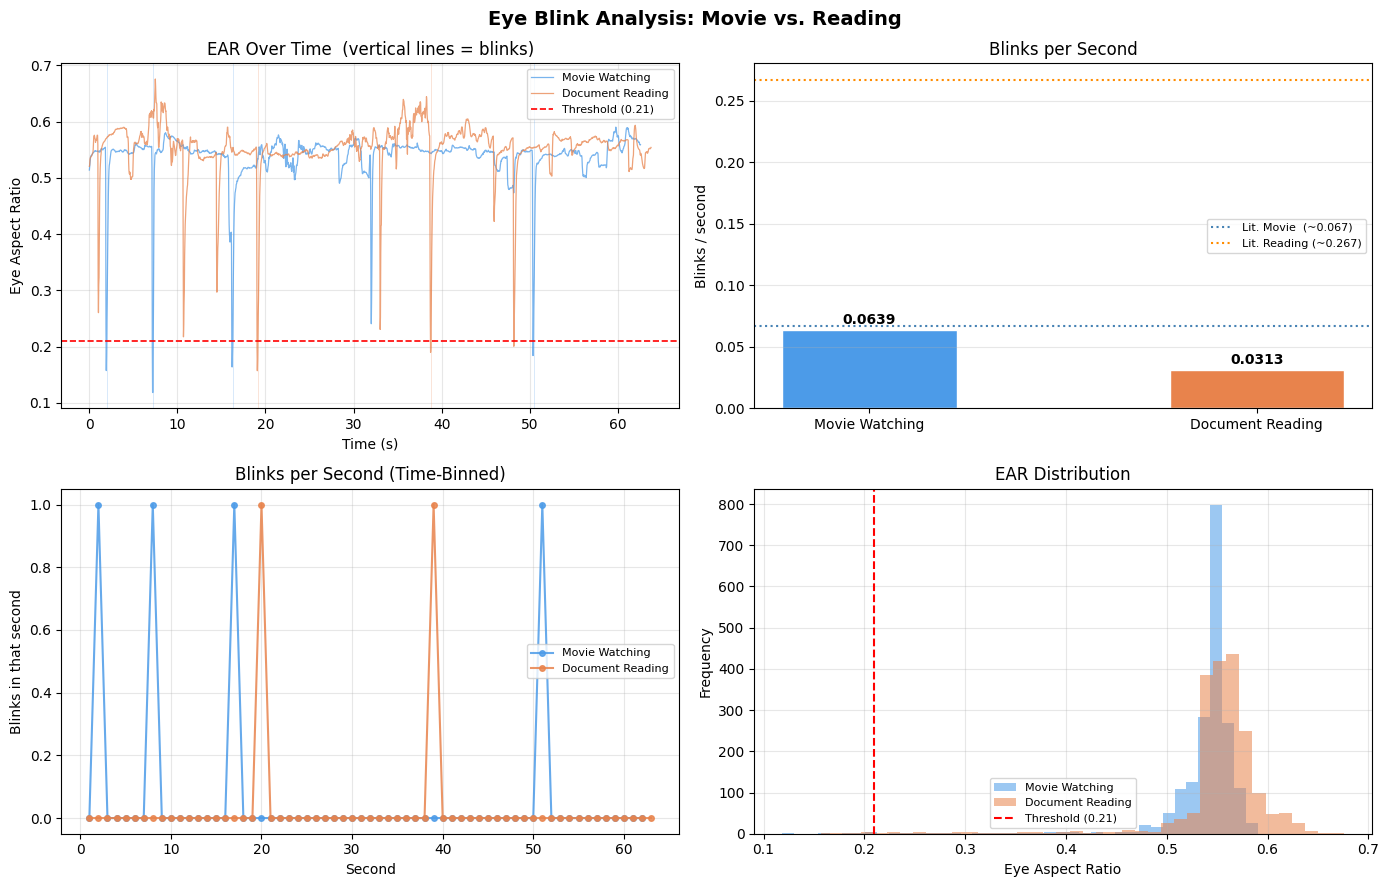

Plot saved → blink_analysis.png


In [13]:
COLORS = {'Movie Watching': '#4C9BE8', 'Document Reading': '#E8834C'}

def print_report(m, r):
    diff = r['blinks_per_sec'] - m['blinks_per_sec']
    pct  = (diff / m['blinks_per_sec'] * 100) if m['blinks_per_sec'] > 0 else float('nan')
    sep  = '=' * 54
    print(sep, '  BLINK RATE REPORT', sep, sep=('\n'))
    for s in [m, r]:
        icon = '🎬' if 'Movie' in s['label'] else '📄'
        print(f"\n  {icon} {s['label']}")
        print(f"     Duration        : {s['duration_s']} s")
        print(f"     Total blinks    : {s['blinks']}")
        print(f"     Blinks / second : {s['blinks_per_sec']}")
        print(f"     Blinks / minute : {s['blinks_per_min']}")
        print(f"     Average EAR     : {s['avg_ear']}")
    print(f'\n  Δ (Reading − Movie) : {diff:+.4f} blinks/s  ({pct:+.1f}%)')
    verdict = ('MORE while reading ✅ (matches literature)' if diff > 0
               else 'MORE while watching 🎬' if diff < 0 else 'equal in both')
    print(f'  → You blinked {verdict}')
    print('\n  Literature baseline:')
    print('     Movie   : ~0.067 blinks/s (~4/min)')
    print('     Reading : ~0.267 blinks/s (~16/min)')
    print(sep)

print_report(movie_stats, reading_stats)

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Eye Blink Analysis: Movie vs. Reading', fontsize=14, fontweight='bold')

# Plot 1 – EAR over time
ax = axes[0, 0]
for s in [movie_stats, reading_stats]:
    if s['timestamps_s']:
        ax.plot(s['timestamps_s'], s['ear_history'], alpha=0.75, lw=0.9,
                label=s['label'], color=COLORS[s['label']])
        for bt in s['blink_times']:
            ax.axvline(bt, color=COLORS[s['label']], alpha=0.25, lw=0.6)
ax.axhline(EAR_THRESHOLD, color='red', ls='--', lw=1.2, label=f'Threshold ({EAR_THRESHOLD})')
ax.set_title('EAR Over Time  (vertical lines = blinks)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Eye Aspect Ratio')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Plot 2 – Bar: blinks per second
ax = axes[0, 1]
lbls = ['Movie Watching', 'Document Reading']
bps_vals = [movie_stats['blinks_per_sec'], reading_stats['blinks_per_sec']]
bars = ax.bar(lbls, bps_vals, color=[COLORS[l] for l in lbls], edgecolor='white', width=0.45)
for bar, val in zip(bars, bps_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(0.067, color='steelblue',  ls=':', lw=1.5, label='Lit. Movie  (~0.067)')
ax.axhline(0.267, color='darkorange', ls=':', lw=1.5, label='Lit. Reading (~0.267)')
ax.set_title('Blinks per Second'); ax.set_ylabel('Blinks / second')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Plot 3 – Per-second blink counts over time
ax = axes[1, 0]
for s in [movie_stats, reading_stats]:
    x = list(range(1, len(s['per_second_blinks']) + 1))
    ax.plot(x, s['per_second_blinks'], marker='o', ms=4,
            label=s['label'], color=COLORS[s['label']], alpha=0.85)
ax.set_title('Blinks per Second (Time-Binned)')
ax.set_xlabel('Second'); ax.set_ylabel('Blinks in that second')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Plot 4 – EAR histogram
ax = axes[1, 1]
for s in [movie_stats, reading_stats]:
    if s['ear_history']:
        ax.hist(s['ear_history'], bins=40, alpha=0.55,
                label=s['label'], color=COLORS[s['label']])
ax.axvline(EAR_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({EAR_THRESHOLD})')
ax.set_title('EAR Distribution')
ax.set_xlabel('Eye Aspect Ratio'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('blink_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → blink_analysis.png')

---
## Background: Why Blink Rates Differ

| Condition | Typical rate | Mechanism |
|---|---|---|
| Movie watching | ~3–5 blinks/min (~0.07/s) | Bright, moving stimuli suppress the blink reflex; the brain prioritises continuous visual intake |
| Document reading | ~12–18 blinks/min (~0.27/s) | Sustained fixation + cognitive load dry the cornea faster, triggering more frequent blinks |

**References:** Bentivoglio et al. (1997); Nakamori et al. (1997); Panse et al. (2021)